## Imports

In [ ]:
# To use Google Drive files Uncomment if nedded
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


# Developed by
Andrés Felipe Figueroa Betancourt

In [3]:
# Data manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML libraries
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

## Data Loading

In [ ]:
FILE_NAME = {
    "train": "training_data.csv",
    "blind_test": "blind_test_data.csv"
}
DATA_PATH = "/content/drive/MyDrive/data"

### Load

#### Train Data

In [5]:
df_train = pd.read_csv(f'{DATA_PATH}/{FILE_NAME["train"]}')
df_train.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,432.475954,289.373016,481.315600,358.755566,802.659004,176.761177,72.648102,720.969179,36.327684,83.768878,...,4.385848,516.789458,19.624422,13.162440,42.351948,35.920392,20.755984,13.814300,384.497136,14.364922
1,517.596250,330.448341,585.920055,22.684031,169.813240,335.601640,284.451476,748.101047,73.701438,358.147215,...,5.563334,2.960064,20.721878,17.740184,1.726915,167.576065,75.492679,2.480979,303.710869,19.984801
2,189.439350,553.888820,165.833790,202.465927,176.695586,321.155049,407.278389,161.245668,282.269025,221.570899,...,4.536947,581.823741,101.695639,0.653592,486.859084,117.491548,6.420465,20.713314,22.651537,12.944351
3,237.307878,195.894881,416.752252,468.729031,611.693517,301.411711,241.880655,49.597044,122.396821,13.828319,...,5.518968,45.014729,196.350455,47.638515,411.414213,67.142022,115.630943,8.927957,388.240433,14.792440
4,602.845256,16.103208,221.759979,345.765574,558.588369,276.704241,408.069566,19.390813,138.769765,146.662193,...,2.136214,133.590430,197.634584,26.278027,111.127557,172.181136,85.869642,30.537857,625.931837,11.802634


In [6]:
# I am just confirming that it has 800 rows and 21 columns
df_train.shape

(800, 21)

In [7]:
# just confirming there are 20 features and one target
df_train.columns

Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9',
       'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14',
       'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19',
       'target'],
      dtype='object')

##### Separate features and target

In [8]:
X = df_train.drop(columns='target')
y = df_train['target']

In [9]:
X.shape

(800, 20)

In [10]:
y.shape

(800,)

#### Test Data

In [11]:
df_test = pd.read_csv(f'{DATA_PATH}/{FILE_NAME["blind_test"]}')
df_test.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
0,676.867615,32.518822,254.825875,502.268510,609.469688,497.624266,105.246239,269.045539,150.177005,312.649860,765.296227,0.237996,660.030637,147.059794,40.232132,464.424834,121.147466,68.284243,26.969870,314.461582
1,628.695228,426.163933,347.070280,431.106903,915.527507,301.699534,1.666992,306.733041,104.234252,63.242070,467.009734,6.608084,600.994184,43.619815,48.153926,457.256565,49.163652,85.511662,33.500538,819.537877
2,131.765943,323.839669,245.399775,181.814398,710.179159,59.117377,312.622788,687.965027,109.803179,381.169500,700.532108,1.822370,736.306092,138.759029,36.915389,436.174065,10.037994,62.631938,6.211169,341.361374
3,160.970195,489.712029,70.482159,309.486269,888.030604,412.655666,216.124989,47.415477,104.139145,326.462385,378.446187,1.686895,485.144327,143.668518,27.168148,309.715497,149.661493,66.415878,15.001753,539.087409
4,419.907137,216.625219,487.887860,253.704462,323.226862,65.744463,271.811469,527.726782,129.805782,168.429679,637.944633,0.948507,365.946758,72.337904,36.232169,302.772338,186.944884,106.514846,3.443809,364.341969


In [12]:
# Confirming 200 samples, 20 features
df_test.shape

(200, 20)

### Small EDA

In [13]:
X.isnull().sum()

,0
feature_0,0
feature_1,0
feature_2,0
feature_3,0
feature_4,0
feature_5,0
feature_6,0
feature_7,0
feature_8,0
feature_9,0


There are no null data, which is quite surprising for a technical test.

In [56]:
X.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,468.181612,301.960218,317.132996,283.213456,485.975950,320.953859,217.136330,387.196289,179.485453,196.003058,401.079696,3.372667,479.841915,100.112096,28.334725,277.205999,91.217615,70.927129,27.385266,457.016407
std,270.797415,170.691136,176.501920,157.698215,272.594030,185.157189,123.660691,235.131376,104.059309,111.042671,228.533579,1.986369,276.304197,59.149794,16.105155,167.385930,53.950523,40.588905,15.509062,270.650146
min,0.916648,0.800119,0.173025,0.308823,0.598527,0.997347,0.402436,0.474825,0.727850,0.264253,1.487605,0.004464,1.706240,0.194306,0.222312,1.726915,0.093789,0.072986,0.101761,0.252919
25%,239.330140,157.338244,167.516318,151.302826,250.305362,158.374610,106.876625,195.037853,94.220273,95.052359,200.478981,1.630150,249.560260,48.132939,14.660437,131.516567,44.357970,34.903031,13.815298,221.270792
50%,477.750620,303.257176,326.310194,294.574403,493.470486,328.722464,217.098090,364.124238,173.364771,199.587048,413.806417,3.349497,468.536888,100.247827,27.953146,275.950814,87.484343,74.429675,27.766111,462.153497
75%,704.650292,448.878174,474.484472,415.806162,720.747672,480.076559,327.411334,588.565017,268.790459,291.546642,614.042096,5.024192,713.291136,149.966755,42.514155,423.110446,137.888018,105.484961,40.402938,688.352373
max,940.771543,595.359858,614.271632,549.896216,950.017444,638.199832,426.308251,809.346792,367.084755,384.919108,767.311089,6.859269,979.715063,203.122292,56.467485,566.611509,187.041256,138.675389,53.254740,935.740775


In [15]:
X.nunique()

,0
feature_0,800
feature_1,800
feature_2,800
feature_3,800
feature_4,800
feature_5,800
feature_6,800
feature_7,800
feature_8,800
feature_9,800


It seems like there are no "hidden" Catehorical variables in all the numerical variables.

In [16]:
y.describe()

,target
count,800.000000
mean,14.631342
std,5.089503
min,0.279805
25%,10.879914
50%,14.687955
75%,18.224713
max,27.360789


In [17]:
y.nunique()

800

And also, the target is not categorical

## Preprocessing

### Train/validation split

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5 #Because I like this number
)

In [19]:
# Small Sanity check
print(f'{X_train.shape = } \n{X_val.shape = } \n{y_train.shape = } \n{y_val.shape = } ')


X_train.shape = (640, 20) 
X_val.shape = (160, 20) 
y_train.shape = (640,) 
y_val.shape = (160,) 


I chose an 80% training / 20% validation split because there's a good amount of data for training and validation.

I also used `random_state` so that anyone running this notebook can get the same results.

In [20]:
y_train.describe()


,target
count,640.000000
mean,14.721968
std,5.091537
min,0.279805
25%,10.978993
50%,14.737993
75%,18.406129
max,27.360789


In [21]:
y_val.describe()


,target
count,160.000000
mean,14.268839
std,5.081086
min,3.532094
25%,10.639802
50%,14.550153
75%,17.527672
max,26.589465


Even when the minimum value in the train target, and validation target are quite diferent; bot splits has similar mean, std a
and percentiles values; So we can confirm that the train and validition target have a similar distribution.

### Scalling?

In [22]:
X_train.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
feature_0,463.506673,270.225689,0.916648,939.792230
feature_1,301.396607,170.686506,0.800119,595.359858
feature_2,314.779060,179.965603,0.173025,614.271632
feature_3,286.471387,156.358801,0.308823,549.896216
feature_4,491.018111,274.539021,0.598527,950.017444
feature_5,325.911118,186.397801,5.877671,638.199832
feature_6,221.602319,123.920069,0.402436,426.308251
feature_7,388.835429,238.489662,0.474825,809.346792
feature_8,182.279909,104.247960,0.727850,367.070295
feature_9,198.373701,110.009342,0.264253,384.919108


Features have different means, std and percentile values; so they have different distributions. It meas what if we want to use a neither tree-model nor Bayes models (linear models, gradient base models or regularized models, neural networks, etc) we must scalling the variables, because it reduce outlier sensitivity, and improve models convergence.

It is because most of the models use the euclidean distance "behind scenes". It means: if we have a feature with a larger magnitude of values, that feature will "dominate" over other features, in  the prediction; so not every feature is equally important.

### Feature Selection

In [23]:
corr_with_target = df_train.corr()['target'].sort_values(
    key=abs,
    ascending=False)
corr_with_target

,target
target,1.000000
feature_2,0.551767
feature_13,0.404697
feature_9,0.361942
feature_11,0.322802
feature_4,-0.062672
feature_18,0.060052
feature_19,-0.053464
feature_1,-0.047162
feature_10,0.045485


I used this "test" to check if there are some suspicious variables with the same correlation value; this could mean that are some redundant feature.

Even if `feature_5`, `feature_15` and `feature_16` have a small correlation, this coefficient gives only linear correlation, and we have a relatively small number of features (without redundant information), so I decided to retain all features.

In [24]:
corr_matrix = X_train.corr().abs()
corr_matrix

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
feature_0,1.000000,0.080681,0.011842,0.045717,0.073971,0.050539,0.065707,0.059184,0.043823,0.014034,0.048812,0.007670,0.093026,0.057622,0.041502,0.011788,0.052278,0.025197,0.036239,0.006801
feature_1,0.080681,1.000000,0.070087,0.046113,0.030169,0.006891,0.011528,0.012430,0.056747,0.006737,0.097946,0.006109,0.030627,0.035249,0.044937,0.006257,0.029450,0.009067,0.009193,0.001691
feature_2,0.011842,0.070087,1.000000,0.005424,0.010089,0.007343,0.004986,0.095562,0.044897,0.010259,0.024461,0.007845,0.040515,0.002212,0.008665,0.040830,0.026029,0.053152,0.017817,0.049018
feature_3,0.045717,0.046113,0.005424,1.000000,0.029774,0.025476,0.023647,0.003573,0.013478,0.038103,0.046464,0.080234,0.062832,0.048406,0.018528,0.002198,0.009717,0.037753,0.080278,0.052295
feature_4,0.073971,0.030169,0.010089,0.029774,1.000000,0.027295,0.015151,0.034522,0.078064,0.111046,0.000781,0.069961,0.061083,0.017776,0.004279,0.055703,0.072638,0.065102,0.020585,0.028202
feature_5,0.050539,0.006891,0.007343,0.025476,0.027295,1.000000,0.010112,0.014167,0.020599,0.001991,0.053990,0.082158,0.041233,0.033843,0.010183,0.032409,0.007391,0.026827,0.047140,0.094337
feature_6,0.065707,0.011528,0.004986,0.023647,0.015151,0.010112,1.000000,0.014110,0.016710,0.041565,0.026506,0.005545,0.018867,0.064586,0.057961,0.007250,0.009634,0.026264,0.076615,0.025558
feature_7,0.059184,0.012430,0.095562,0.003573,0.034522,0.014167,0.014110,1.000000,0.045766,0.022586,0.022142,0.028521,0.002667,0.019069,0.001779,0.009370,0.026100,0.006474,0.065605,0.055278
feature_8,0.043823,0.056747,0.044897,0.013478,0.078064,0.020599,0.016710,0.045766,1.000000,0.016180,0.022113,0.038614,0.019039,0.085785,0.006222,0.031152,0.086471,0.011787,0.066620,0.062531
feature_9,0.014034,0.006737,0.010259,0.038103,0.111046,0.001991,0.041565,0.022586,0.016180,1.000000,0.067230,0.032938,0.014585,0.010833,0.029566,0.014681,0.030996,0.015673,0.008151,0.022911


In [25]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

high_corr_features

[]

Whit these I just check again there are no redundant features.

## Modeling

### Linear Regression (Baseline)

In [26]:
pipeline_lr = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [27]:
y_train_pred = pipeline_lr.predict(X_train)
y_val_pred = pipeline_lr.predict(X_val)

r2_train_lr = r2_score(y_train, y_train_pred)
r2_val_lr = r2_score(y_val, y_val_pred)

rmse_train_lr = mean_squared_error(y_train, y_train_pred)
rmse_val_lr = mean_squared_error(y_val, y_val_pred)

print(f"LINEAR MODEL \n{r2_train_lr = } \n{r2_val_lr = } \n{rmse_train_lr = } \n{rmse_val_lr = }")

LINEAR MODEL 
r2_train_lr = 0.7262050044928852 
r2_val_lr = 0.6053228020507846 
rmse_train_lr = 7.0867030367104675 
rmse_val_lr = 10.125868243078495


The big gap between train and validation R2 is suspicious, but this is just a baseline model, I am going to continue for now.

### Ridge Regression

This model is usually good reducing noise

In [28]:
pipeline_ridge = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipeline_ridge.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

In [29]:
y_train_pred = pipeline_ridge.predict(X_train)
y_val_pred = pipeline_ridge.predict(X_val)

r2_train_ridge = r2_score(y_train, y_train_pred)
r2_val_ridge = r2_score(y_val, y_val_pred)

rmse_train_ridge = mean_squared_error(y_train, y_train_pred)
rmse_val_ridge = mean_squared_error(y_val, y_val_pred)

print(f"RIDGE MODEL \n{r2_train_ridge = } \n{r2_val_ridge = } \n{rmse_train_ridge = } \n{rmse_val_ridge = }")

RIDGE MODEL 
r2_train_ridge = 0.7262031497076907 
r2_val_ridge = 0.6055440863242672 
rmse_train_ridge = 7.086751044570677 
rmse_val_ridge = 10.120190956908448


The performance values almost doesn't change, this is so suspicious.

In [30]:
coef_lr = pipeline_lr.named_steps['model'].coef_
coef_ridge = pipeline_ridge.named_steps['model'].coef_

pd.DataFrame({
    'Linear': coef_lr,
    'Ridge': coef_ridge
}, index=X_train.columns)

,Linear,Ridge
feature_0,0.000406,0.000616
feature_1,0.008391,0.007994
feature_2,2.782004,2.777577
feature_3,0.149867,0.149046
feature_4,0.043549,0.042719
feature_5,-0.045294,-0.045214
feature_6,0.096247,0.096450
feature_7,-0.008567,-0.008114
feature_8,0.054156,0.054246
feature_9,1.997020,1.993655


Ridge regression produced very similar performance to linear regression, suggesting that the problem is well-conditioned, with low multicollinearity and sufficient data relative to the number of features. Regularization did not significantly improve generalization, which indicates that variance is not the main limitation.

### Random Forest

In [31]:
# No scalling needed
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=5 # Again, it is because I like this number
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=5)

In [32]:
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)

r2_train_rf = r2_score(y_train, y_train_pred)
r2_val_rf = r2_score(y_val, y_val_pred)

rmse_train_rf = mean_squared_error(y_train, y_train_pred)
rmse_val_rf = mean_squared_error(y_val, y_val_pred)

print(f"RANDOM FOREST \n{r2_train_rf = } \n{r2_val_rf = } \n{rmse_train_rf = } \n{rmse_val_rf = }")

RANDOM FOREST 
r2_train_rf = 0.9661711025457854 
r2_val_rf = 0.7471930311438612 
rmse_train_rf = 0.8756016517881147 
rmse_val_rf = 6.486034842830472


The huge gap between train and validation R2 values, usually means overfitting.

I'm going to try with more complex models, before tuning.

### Gradient Boosting Regressor

In [33]:
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=5
)

gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=5)

In [34]:
# No scalling needed
y_train_pred = gbr_model.predict(X_train)
y_val_pred = gbr_model.predict(X_val)

r2_train_gbr = r2_score(y_train, y_train_pred)
r2_val_gbr = r2_score(y_val, y_val_pred)

rmse_train_gbr = mean_squared_error(y_train, y_train_pred)
rmse_val_gbr = mean_squared_error(y_val, y_val_pred)

print(f"GRADIENT BOOST \n{r2_train_gbr = } \n{r2_val_gbr = } \n{rmse_train_gbr = } \n{rmse_val_gbr = }")


GRADIENT BOOST 
r2_train_gbr = 0.9703776425917767 
r2_val_gbr = 0.8210041256638281 
rmse_train_gbr = 0.7667227438199231 
rmse_val_gbr = 4.5923317815181495


### Extra Trees Regressor

In [35]:
etr_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=5
)

etr_model.fit(X_train, y_train)

ExtraTreesRegressor(min_samples_leaf=2, n_estimators=400, random_state=5)

In [36]:
y_train_pred = etr_model.predict(X_train)
y_val_pred = etr_model.predict(X_val)

r2_train_etr = r2_score(y_train, y_train_pred)
r2_val_etr = r2_score(y_val, y_val_pred)

rmse_train_etr = mean_squared_error(y_train, y_train_pred)
rmse_val_etr = mean_squared_error(y_val, y_val_pred)

print(f"EXTRA TREES REGRESSOR \n{r2_train_etr = } \n{r2_val_etr = } \n{rmse_train_etr = } \n{rmse_val_etr = }")

EXTRA TREES REGRESSOR 
r2_train_etr = 0.9936426976609124 
r2_val_etr = 0.7612217908042835 
rmse_train_etr = 0.16454761603021278 
rmse_val_etr = 6.126111916769946


### XGBoost

In [37]:
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=5,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=-1, num_parallel_tree=None, ...)

In [38]:
y_train_pred = xgb_model.predict(X_train)
y_val_pred = xgb_model.predict(X_val)

r2_train_xgb = r2_score(y_train, y_train_pred)
r2_val_xgb = r2_score(y_val, y_val_pred)

rmse_train_xgb = mean_squared_error(y_train, y_train_pred)
rmse_val_xgb = mean_squared_error(y_val, y_val_pred)

print(f"EXBOOST \n{r2_train_xgb = } \n{r2_val_xgb = } \n{rmse_train_xgb = } \n{rmse_val_xgb = }")

EXBOOST 
r2_train_xgb = 0.9815723852562614 
r2_val_xgb = 0.8417899299614453 
rmse_train_xgb = 0.4769664731157926 
rmse_val_xgb = 4.059049603734044


### Result Comparision

In [39]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting Regression', 'Extra Trees Regresion', 'XGBoost'],
    'R2_train': [r2_train_lr, r2_train_ridge, r2_train_rf, r2_train_gbr, r2_train_etr, r2_train_xgb],
    'R2_val': [r2_val_lr, r2_val_ridge, r2_val_rf, r2_val_gbr, r2_val_etr, r2_val_xgb],
    'RMSE_train': [rmse_train_lr, rmse_train_ridge, rmse_train_rf, rmse_train_gbr, rmse_train_etr, rmse_train_xgb],
    'RMSE_val': [rmse_val_lr, rmse_val_ridge, rmse_val_rf, rmse_val_gbr, rmse_val_etr, rmse_val_xgb],
})

results

,Model,R2_train,R2_val,RMSE_train,RMSE_val
0,Linear Regression,0.726205,0.605323,7.086703,10.125868
1,Ridge Regression,0.726203,0.605544,7.086751,10.120191
2,Random Forest,0.966171,0.747193,0.875602,6.486035
3,Gradient Boosting Regression,0.970378,0.821004,0.766723,4.592332
4,Extra Trees Regresion,0.993643,0.761222,0.164548,6.126112
5,XGBoost,0.981572,0.841790,0.476966,4.059050


## Model Tuning

### `max_depth`, `min_child_weight`

In [40]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=5,
    n_jobs=-1
)

In [41]:
param_grid_stage1 = {
    'max_depth': [2, 3, 4],
    'min_child_weight': [1, 3, 5]
}

grid_stage1 = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_stage1,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_stage1.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=0.05, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=3, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=400,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4], 'min_child_weight': [1, 3, 5]},
             scoring='r2')

In [42]:
grid_stage1.best_params_

{'max_depth': 3, 'min_child_weight': 3}

### `subsample`, `colsample_bytree`

In [43]:
best_stage1 = grid_stage1.best_params_

xgb_stage2 = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.05,
    n_estimators=400,
    random_state=5,
    n_jobs=-1,
    **best_stage1
)

param_grid_stage2 = {
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_stage2 = GridSearchCV(
    estimator=xgb_stage2,
    param_grid=param_grid_stage2,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_stage2.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=0.05, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=3, max_leaves=None,
                                    min_child_weight=3, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=400,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='r2')

In [44]:
best_stage2 = grid_stage2.best_params_
best_stage2

{'colsample_bytree': 1.0, 'subsample': 0.8}

### `learning_rate`, `n_stimators`

In [45]:
param_grid_stage3 = {
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 700]
}

xgb_stage3 = XGBRegressor(
    objective='reg:squarederror',
    max_depth=best_stage1['max_depth'],
    min_child_weight=best_stage1['min_child_weight'],
    subsample=best_stage2['subsample'],
    colsample_bytree=best_stage2['colsample_bytree'],
    random_state=5,
    n_jobs=-1
)

grid_stage3 = GridSearchCV(
    estimator=xgb_stage3,
    param_grid=param_grid_stage3,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_stage3.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=1.0,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=3, max_leaves=None,
                                    min_child_weight=3, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.05, 0.1],
                         'n_estimators': [300, 500, 700]},
             scoring='r2')

In [46]:
grid_stage3.best_params_

{'learning_rate': 0.05, 'n_estimators': 500}

### Best one

In [47]:
best_xgb = grid_stage3.best_estimator_

In [48]:
y_train_pred = best_xgb.predict(X_train)
y_val_pred = best_xgb.predict(X_val)

r2_train_xgb_best = r2_score(y_train, y_train_pred)
r2_val_xgb_best = r2_score(y_val, y_val_pred)

rmse_train_xgb_best = mean_squared_error(y_train, y_train_pred)
rmse_val_xgb_best = mean_squared_error(y_val, y_val_pred)

print(f"BEST_XGB \n{r2_train_xgb_best = } \n{r2_val_xgb_best = } \n{rmse_train_xgb_best = } \n{rmse_val_xgb_best = }")

BEST_XGB 
r2_train_xgb_best = 0.9877572214548398 
r2_val_xgb_best = 0.841665117559647 
rmse_train_xgb_best = 0.3168828405101591 
rmse_val_xgb_best = 4.062251800218358


In [49]:
train_sizes, train_scores, val_scores = learning_curve(
    best_xgb,
    X,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

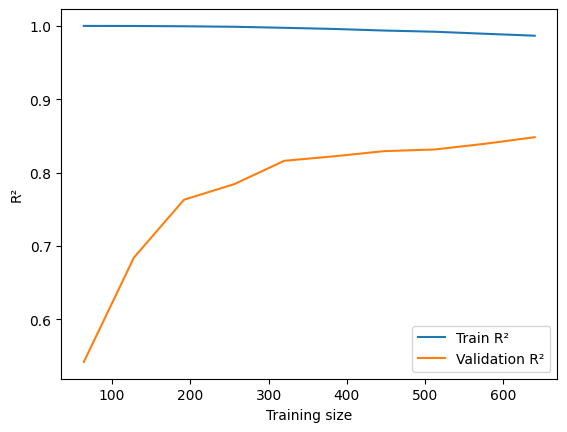

In [50]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label='Train R²')
plt.plot(train_sizes, val_mean, label='Validation R²')
plt.xlabel('Training size')
plt.ylabel('R²')
plt.legend()
plt.show()

I'm not very happy with this result (It seems Overfitting). But I don't have so much time, so I am going to use this model and assume that perhaps with more data the model could improve his performance.

## Evaluation

In [51]:
final_model = XGBRegressor(
    objective='reg:squarederror',
    max_depth=best_stage1['max_depth'],
    min_child_weight=best_stage1['min_child_weight'],
    subsample=best_stage2['subsample'],
    colsample_bytree=best_stage2['colsample_bytree'],
    n_estimators=grid_stage3.best_params_['n_estimators'],
    learning_rate=grid_stage3.best_params_['learning_rate'],
    random_state=5,
    n_jobs=-1
)

final_model.fit(X, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

## Prediction

In [52]:
test_predictions = final_model.predict(df_test)

In [53]:
submission = pd.DataFrame({
    'target_pred': test_predictions
})

output_path = f'{DATA_PATH}/target_predictions.csv'
submission.to_csv(output_path, index=False)


In [54]:
# Just to safety check the results
solution = pd.read_csv(output_path)
solution.head()

,target_pred
0,12.382915
1,12.211355
2,15.397385
3,12.304020
4,17.533220


In [55]:
solution.shape

(200, 1)